# 01 - EDA and Sleep Pattern Analysis

Initial checks for schema, missing values, target distribution, and sleep-related relationships.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.config import TARGET_COLUMN
from src.data import load_raw_data

train, test, sample = load_raw_data()
train.shape, test.shape, sample.head()

((56000, 24),
 (24000, 23),
    id  bilissel_performans_skoru
 0   1                       7.85
 1   2                       4.32)

In [2]:
display(train.head())
display(train[TARGET_COLUMN].describe())
display(train.isna().sum()[train.isna().sum() > 0].sort_values(ascending=False))
display(test.isna().sum()[test.isna().sum() > 0].sort_values(ascending=False))

,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


count    56000.000000
mean         5.913096
std          2.231759
min          0.000000
25%          4.397431
50%          6.032249
75%          7.574980
max         10.000000
Name: bilissel_performans_skoru, dtype: float64

kronotip                 1968
vucut_kitle_indeksi      1752
stres_skoru              1715
uyku_oncesi_kafein_mg    1463
meslek                   1378
ruh_sagligi_durumu       1096
dtype: int64

kronotip                 832
stres_skoru              765
uyku_oncesi_kafein_mg    697
vucut_kitle_indeksi      648
meslek                   622
ruh_sagligi_durumu       504
dtype: int64

stres_skoru                   -0.586676
rem_yuzdesi                    0.442999
gunluk_calisma_saati          -0.342112
derin_uyku_yuzdesi             0.280006
gecelik_uyanma_sayisi         -0.270349
uykuya_dalma_suresi_dk        -0.207349
gunluk_adim_sayisi             0.134042
dinlenik_nabiz_bpm            -0.089389
yas                           -0.070659
uyku_oncesi_kafein_mg         -0.062387
uyku_oncesi_ekran_suresi_dk   -0.044631
vucut_kitle_indeksi           -0.037990
sekerleme_suresi_dk           -0.023683
oda_sicakligi_celsius         -0.011992
hafta_sonu_uyku_farki_saat    -0.001648
dtype: float64

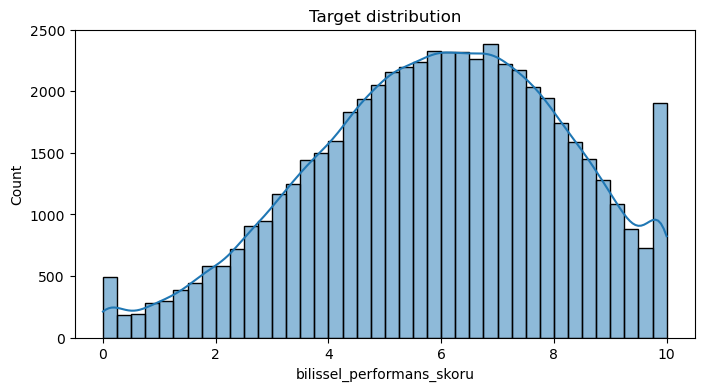

In [3]:
numeric = train.select_dtypes('number').drop(columns=['id', TARGET_COLUMN])
corr = numeric.corrwith(train[TARGET_COLUMN]).sort_values(key=lambda s: s.abs(), ascending=False)
display(corr)

plt.figure(figsize=(8, 4))
sns.histplot(train[TARGET_COLUMN], bins=40, kde=True)
plt.title('Target distribution')
plt.show()

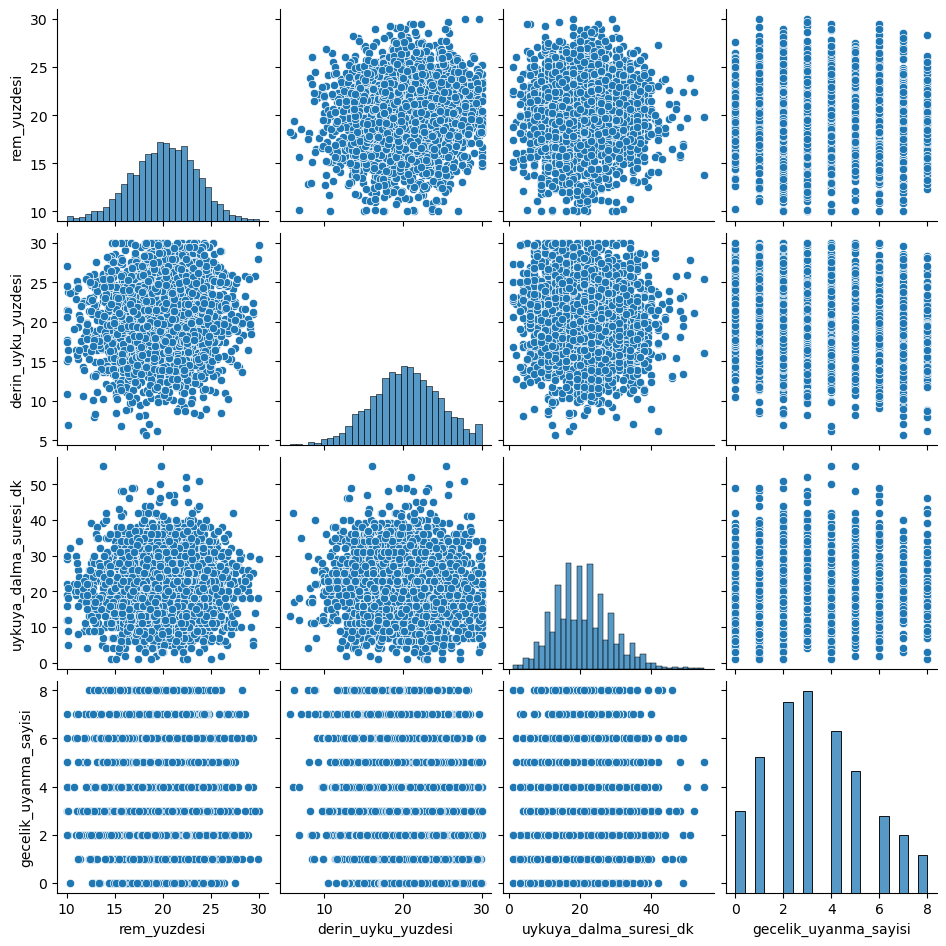

In [4]:
sleep_cols = ['rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk', 'gecelik_uyanma_sayisi']
sns.pairplot(train.sample(3000, random_state=42), vars=sleep_cols, y_vars=[TARGET_COLUMN], height=2.4)
plt.show()

In [5]:
for col in train.select_dtypes(exclude='number').columns:
    display(train.groupby(col, dropna=False)[TARGET_COLUMN].agg(['count', 'mean', 'std']).sort_values('mean'))

,count,mean,std
cinsiyet,,,
Kadin,28676,5.912420,2.238586
Erkek,27324,5.913804,2.224613


,count,mean,std
meslek,,,
Lawyer,2742,4.719782,2.125938
Saglik Personeli,9842,4.930272,2.190316
Lojistik Calisani,3811,5.119135,2.166604
Ogrenci,8132,5.535248,2.111092
Yonetici,4454,5.729820,2.127878
Satis ve Pazarlama Calisani,3899,6.010286,2.055236
NaN,1378,6.022928,2.309071
Muhendis,6533,6.223087,2.040621
Egitimci,4395,6.343725,2.011186


,count,mean,std
ulke,,,
Fransa,3440,5.855670,2.229223
Sweden,566,5.874886,2.217079
South Korea,2189,5.882008,2.199693
Amerika,4447,5.884016,2.208927
Arjantin,3973,5.888813,2.240050
Portekiz,2204,5.905152,2.255888
Guney Kore,4459,5.909655,2.208531
Cin,9989,5.912783,2.234246
Ingiltere,11324,5.915436,2.247550


,count,mean,std
kronotip,,,
Gece insani,15938,5.797330,2.235135
Notr,24594,5.934548,2.227339
Sabah insani,13500,5.995613,2.230439
NaN,1968,6.016487,2.231868


,count,mean,std
ruh_sagligi_durumu,,,
Anksiyete ve depresyon,2765,3.590186,2.046661
Depresyon,5504,4.394400,2.011677
Anksiyete,8270,5.012262,2.097732
NaN,1096,5.939361,2.184929
Saglikli,38365,6.491822,2.018310


,count,mean,std
mevsim,,,
Ilkbahar-Yaz,28143,5.910262,2.237640
Sonbahar-Kis,27857,5.915958,2.225839


,count,mean,std
gun_tipi,,,
Hafta ici,40052,5.482975,2.195082
Hafta sonu,15948,6.993307,1.938364
